In [1]:
!pip install open_spiel
!pip install pokerkit
!pip install networkx matplotlib

## Load Your First Extensive Form Game

In [2]:
import pyspiel

# load game
game = pyspiel.load_game("kuhn_poker")

print("Game:", game)

# initial state
state = game.new_initial_state()

print("\nInitial State:")
print(state)

print("\nGame Type:")
print(game.get_type())

Game: kuhn_poker()

Initial State:


Game Type:
<GameType 'kuhn_poker'>


### Understnding the game we are working with

In [6]:
state.is_chance_node()

True

In [7]:
state.current_player()

-1

In [8]:
state.legal_actions()

[0, 1, 2]

In [9]:
state.is_terminal()

False

In [10]:
state.returns()

[0.0, 0.0]

In [11]:
state.chance_outcomes()

[(0, 0.3333333333333333), (1, 0.3333333333333333), (2, 0.3333333333333333)]

In [14]:
state.information_state_string(1)

''

## Explore the game tree

In [19]:
def explore_tree(state, depth=0):
    
    if state.is_terminal():
        print("  "*depth, "Terminal -> payoff:", state.returns())
        return

    if state.is_chance_node():
        print("  "*depth, "Chance node")
        for action, prob in state.chance_outcomes():
            print("  "*depth, "chance action:", action, "prob:", prob)
            new_state = state.clone()
            new_state.apply_action(action)
            explore_tree(new_state, depth+1)

    else:
        player = state.current_player()
        print("  "*depth, "Player", player, "actions:", state.legal_actions())

        for action in state.legal_actions():
            new_state = state.clone()
            new_state.apply_action(action)
            explore_tree(new_state, depth+1)


explore_tree(state)

 Chance node
 chance action: 0 prob: 0.3333333333333333
   Chance node
   chance action: 1 prob: 0.5
     Player 0 actions: [0, 1]
       Player 1 actions: [0, 1]
         Terminal -> payoff: [-1.0, 1.0]
         Player 0 actions: [0, 1]
           Terminal -> payoff: [-1.0, 1.0]
           Terminal -> payoff: [-2.0, 2.0]
       Player 1 actions: [0, 1]
         Terminal -> payoff: [1.0, -1.0]
         Terminal -> payoff: [-2.0, 2.0]
   chance action: 2 prob: 0.5
     Player 0 actions: [0, 1]
       Player 1 actions: [0, 1]
         Terminal -> payoff: [-1.0, 1.0]
         Player 0 actions: [0, 1]
           Terminal -> payoff: [-1.0, 1.0]
           Terminal -> payoff: [-2.0, 2.0]
       Player 1 actions: [0, 1]
         Terminal -> payoff: [1.0, -1.0]
         Terminal -> payoff: [-2.0, 2.0]
 chance action: 1 prob: 0.3333333333333333
   Chance node
   chance action: 0 prob: 0.5
     Player 0 actions: [0, 1]
       Player 1 actions: [0, 1]
         Terminal -> payoff: [1.0, -1.0]
    

## Print Information Sets

In [20]:
state = game.new_initial_state()

def explore_info(state):

    if state.is_terminal():
        return

    if state.is_chance_node():
        for action, _ in state.chance_outcomes():
            s = state.clone()
            s.apply_action(action)
            explore_info(s)
    else:
        print("Player:", state.current_player())
        print("Information state:", state.information_state_string())
        print("Legal actions:", state.legal_actions())
        print()

        for action in state.legal_actions():
            s = state.clone()
            s.apply_action(action)
            explore_info(s)

explore_info(state)

Player: 0
Information state: 0
Legal actions: [0, 1]

Player: 1
Information state: 1p
Legal actions: [0, 1]

Player: 0
Information state: 0pb
Legal actions: [0, 1]

Player: 1
Information state: 1b
Legal actions: [0, 1]

Player: 0
Information state: 0
Legal actions: [0, 1]

Player: 1
Information state: 2p
Legal actions: [0, 1]

Player: 0
Information state: 0pb
Legal actions: [0, 1]

Player: 1
Information state: 2b
Legal actions: [0, 1]

Player: 0
Information state: 1
Legal actions: [0, 1]

Player: 1
Information state: 0p
Legal actions: [0, 1]

Player: 0
Information state: 1pb
Legal actions: [0, 1]

Player: 1
Information state: 0b
Legal actions: [0, 1]

Player: 0
Information state: 1
Legal actions: [0, 1]

Player: 1
Information state: 2p
Legal actions: [0, 1]

Player: 0
Information state: 1pb
Legal actions: [0, 1]

Player: 1
Information state: 2b
Legal actions: [0, 1]

Player: 0
Information state: 2
Legal actions: [0, 1]

Player: 1
Information state: 0p
Legal actions: [0, 1]

Player: 0
I

## Run Built in CFR

In [21]:
from open_spiel.python.algorithms import cfr

solver = cfr.CFRSolver(game)

for i in range(1000):
    solver.evaluate_and_update_policy()

policy = solver.average_policy()

print(policy)

## To print the strategy properly

In [22]:
import pyspiel

for state in policy.states:
    print("Information State:", state)
    action_probs = policy.action_probabilities(state)

    for action, prob in action_probs.items():
        print("  Action:", action, "Probability:", prob)

    print()

Information State: 0 1
  Action: 0 Probability: 0.8060180241057096
  Action: 1 Probability: 0.19398197589429045

Information State: 0 1 pb
  Action: 0 Probability: 0.9996898332388071
  Action: 1 Probability: 0.00031016676119293866

Information State: 1 0
  Action: 0 Probability: 0.9925079185990724
  Action: 1 Probability: 0.007492081400927672

Information State: 1 0 pb
  Action: 0 Probability: 0.4694587905279552
  Action: 1 Probability: 0.5305412094720448

Information State: 2 0
  Action: 0 Probability: 0.41588375032927416
  Action: 1 Probability: 0.5841162496707258

Information State: 2 0 pb
  Action: 0 Probability: 0.0006011295218965955
  Action: 1 Probability: 0.9993988704781034

Information State: 0 1 p
  Action: 0 Probability: 0.9965
  Action: 1 Probability: 0.0035

Information State: 0 1 b
  Action: 0 Probability: 0.6635936422215174
  Action: 1 Probability: 0.33640635777848255

Information State: 0 2 p
  Action: 0 Probability: 0.001
  Action: 1 Probability: 0.999

Information Sta

## Verify the game Type

In [23]:
gt = game.get_type()

print("Short Name:", gt.short_name)
print("Dynamics:", gt.dynamics)
print("Chance Mode:", gt.chance_mode)
print("Information:", gt.information)
print("Utility:", gt.utility)
print("Reward Model:", gt.reward_model)
print("Max Players:", gt.max_num_players)
print("Min Players:", gt.min_num_players)

Short Name: kuhn_poker
Dynamics: Dynamics.SEQUENTIAL
Chance Mode: ChanceMode.EXPLICIT_STOCHASTIC
Information: Information.IMPERFECT_INFORMATION
Utility: Utility.ZERO_SUM
Reward Model: RewardModel.TERMINAL
Max Players: 10
Min Players: 2


## Visualize the whole game tree

In [24]:
def print_tree(state, depth=0):

    indent = "  " * depth

    if state.is_terminal():
        print(indent, "Terminal:", state.returns())
        return

    if state.is_chance_node():
        print(indent, "Chance Node")
        for action, prob in state.chance_outcomes():
            new_state = state.clone()
            new_state.apply_action(action)
            print(indent, "Chance Action:", action, "Prob:", prob)
            print_tree(new_state, depth+1)

    else:
        player = state.current_player()
        print(indent, "Player", player, "State:", state)

        for action in state.legal_actions():
            new_state = state.clone()
            new_state.apply_action(action)
            print(indent, "Action:", action)
            print_tree(new_state, depth+1)


state = game.new_initial_state()
print_tree(state)

 Chance Node
 Chance Action: 0 Prob: 0.3333333333333333
   Chance Node
   Chance Action: 1 Prob: 0.5
     Player 0 State: 0 1
     Action: 0
       Player 1 State: 0 1 p
       Action: 0
         Terminal: [-1.0, 1.0]
       Action: 1
         Player 0 State: 0 1 pb
         Action: 0
           Terminal: [-1.0, 1.0]
         Action: 1
           Terminal: [-2.0, 2.0]
     Action: 1
       Player 1 State: 0 1 b
       Action: 0
         Terminal: [1.0, -1.0]
       Action: 1
         Terminal: [-2.0, 2.0]
   Chance Action: 2 Prob: 0.5
     Player 0 State: 0 2
     Action: 0
       Player 1 State: 0 2 p
       Action: 0
         Terminal: [-1.0, 1.0]
       Action: 1
         Player 0 State: 0 2 pb
         Action: 0
           Terminal: [-1.0, 1.0]
         Action: 1
           Terminal: [-2.0, 2.0]
     Action: 1
       Player 1 State: 0 2 b
       Action: 0
         Terminal: [1.0, -1.0]
       Action: 1
         Terminal: [-2.0, 2.0]
 Chance Action: 1 Prob: 0.3333333333333333
   Cha

## View Exploitability

In [25]:
from open_spiel.python.algorithms import exploitability

exploit = exploitability.exploitability(game, policy)
print("Exploitability:", exploit)

Exploitability: 0.0009376166469929614


## Visualize the Full Kuhn Poker Game Tree

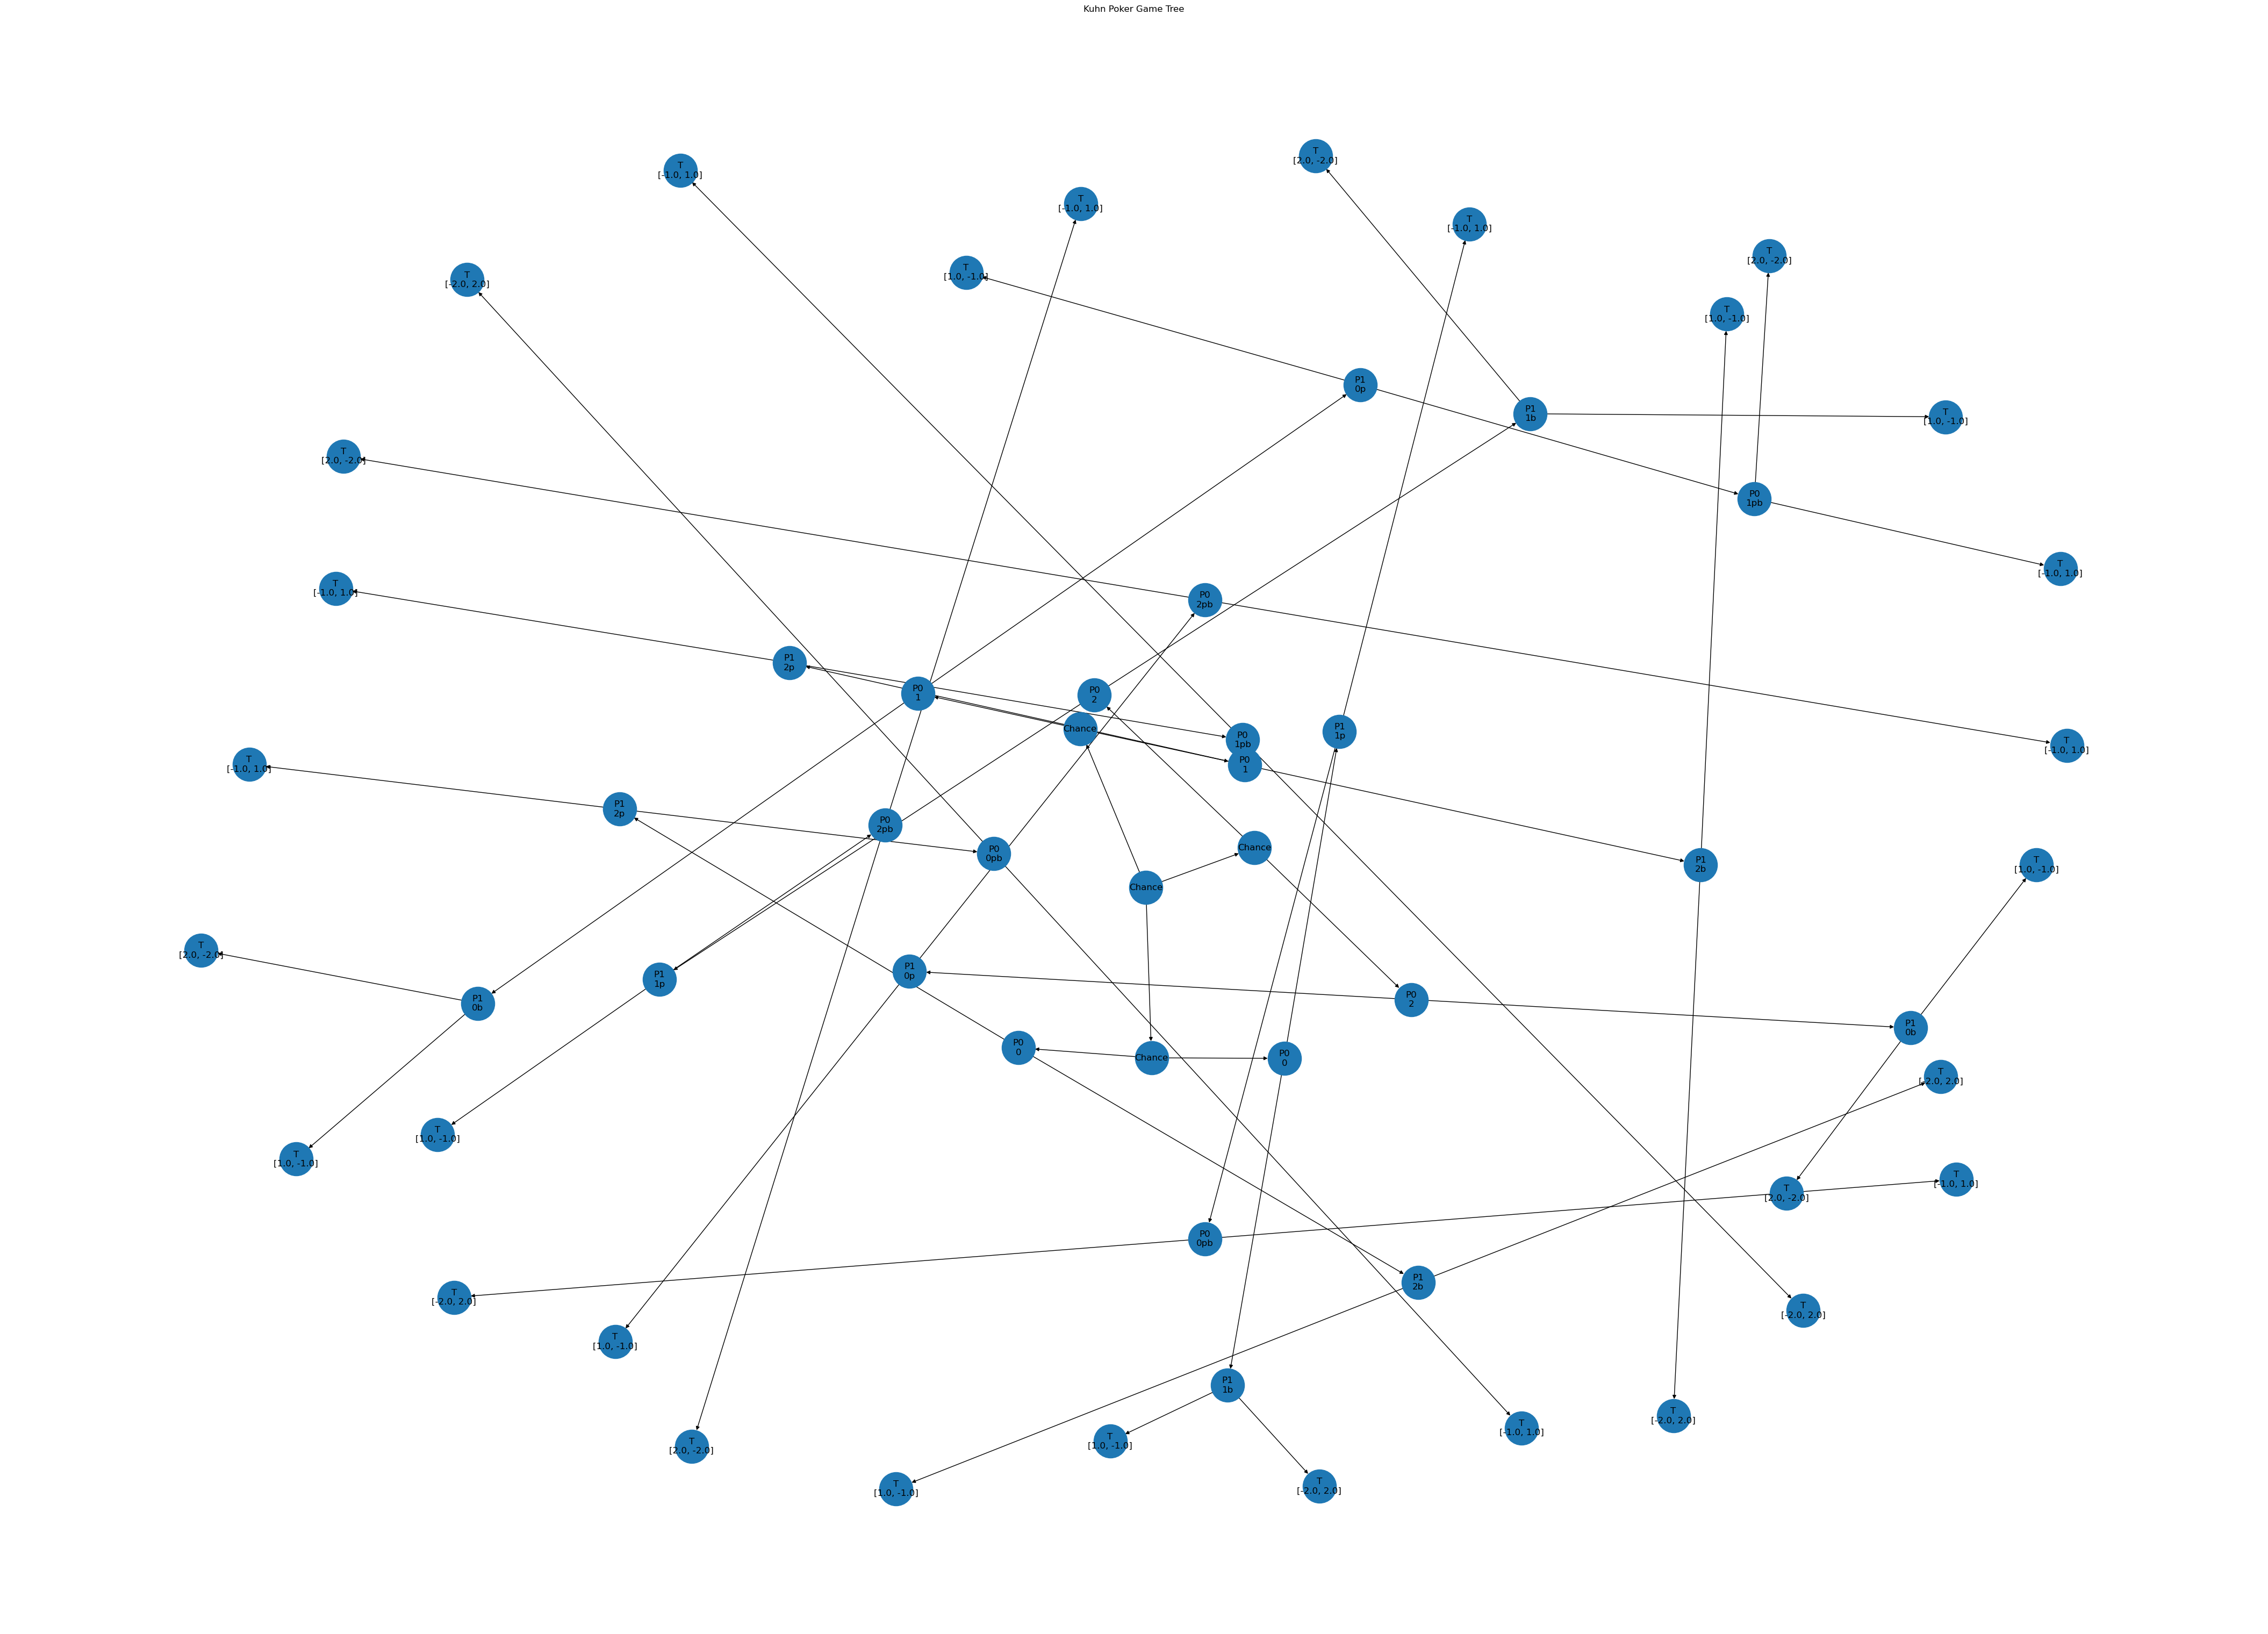

In [28]:
import pyspiel
import networkx as nx
import matplotlib.pyplot as plt

# Load game
game = pyspiel.load_game("kuhn_poker")
state = game.new_initial_state()

G = nx.DiGraph()

node_counter = 0

def traverse(state, parent=None):
    global node_counter
    
    node_id = node_counter
    node_counter += 1
    
    # label for node
    if state.is_terminal():
        label = f"T\n{state.returns()}"
    elif state.is_chance_node():
        label = "Chance"
    else:
        label = f"P{state.current_player()}\n{state.information_state_string()}"
    
    G.add_node(node_id, label=label)
    
    if parent is not None:
        G.add_edge(parent, node_id)
    
    if state.is_terminal():
        return
    
    if state.is_chance_node():
        for action, prob in state.chance_outcomes():
            new_state = state.clone()
            new_state.apply_action(action)
            traverse(new_state, node_id)
    else:
        for action in state.legal_actions():
            new_state = state.clone()
            new_state.apply_action(action)
            traverse(new_state, node_id)

# Build tree
traverse(state)

# Layout
pos = nx.spring_layout(G, seed=42)

labels = nx.get_node_attributes(G, 'label')

plt.figure(figsize=(42,30))
nx.draw(G, pos, with_labels=False, node_size=2000)
nx.draw_networkx_labels(G, pos, labels)
plt.title("Kuhn Poker Game Tree")
plt.show()

## Visualize the whole game tree

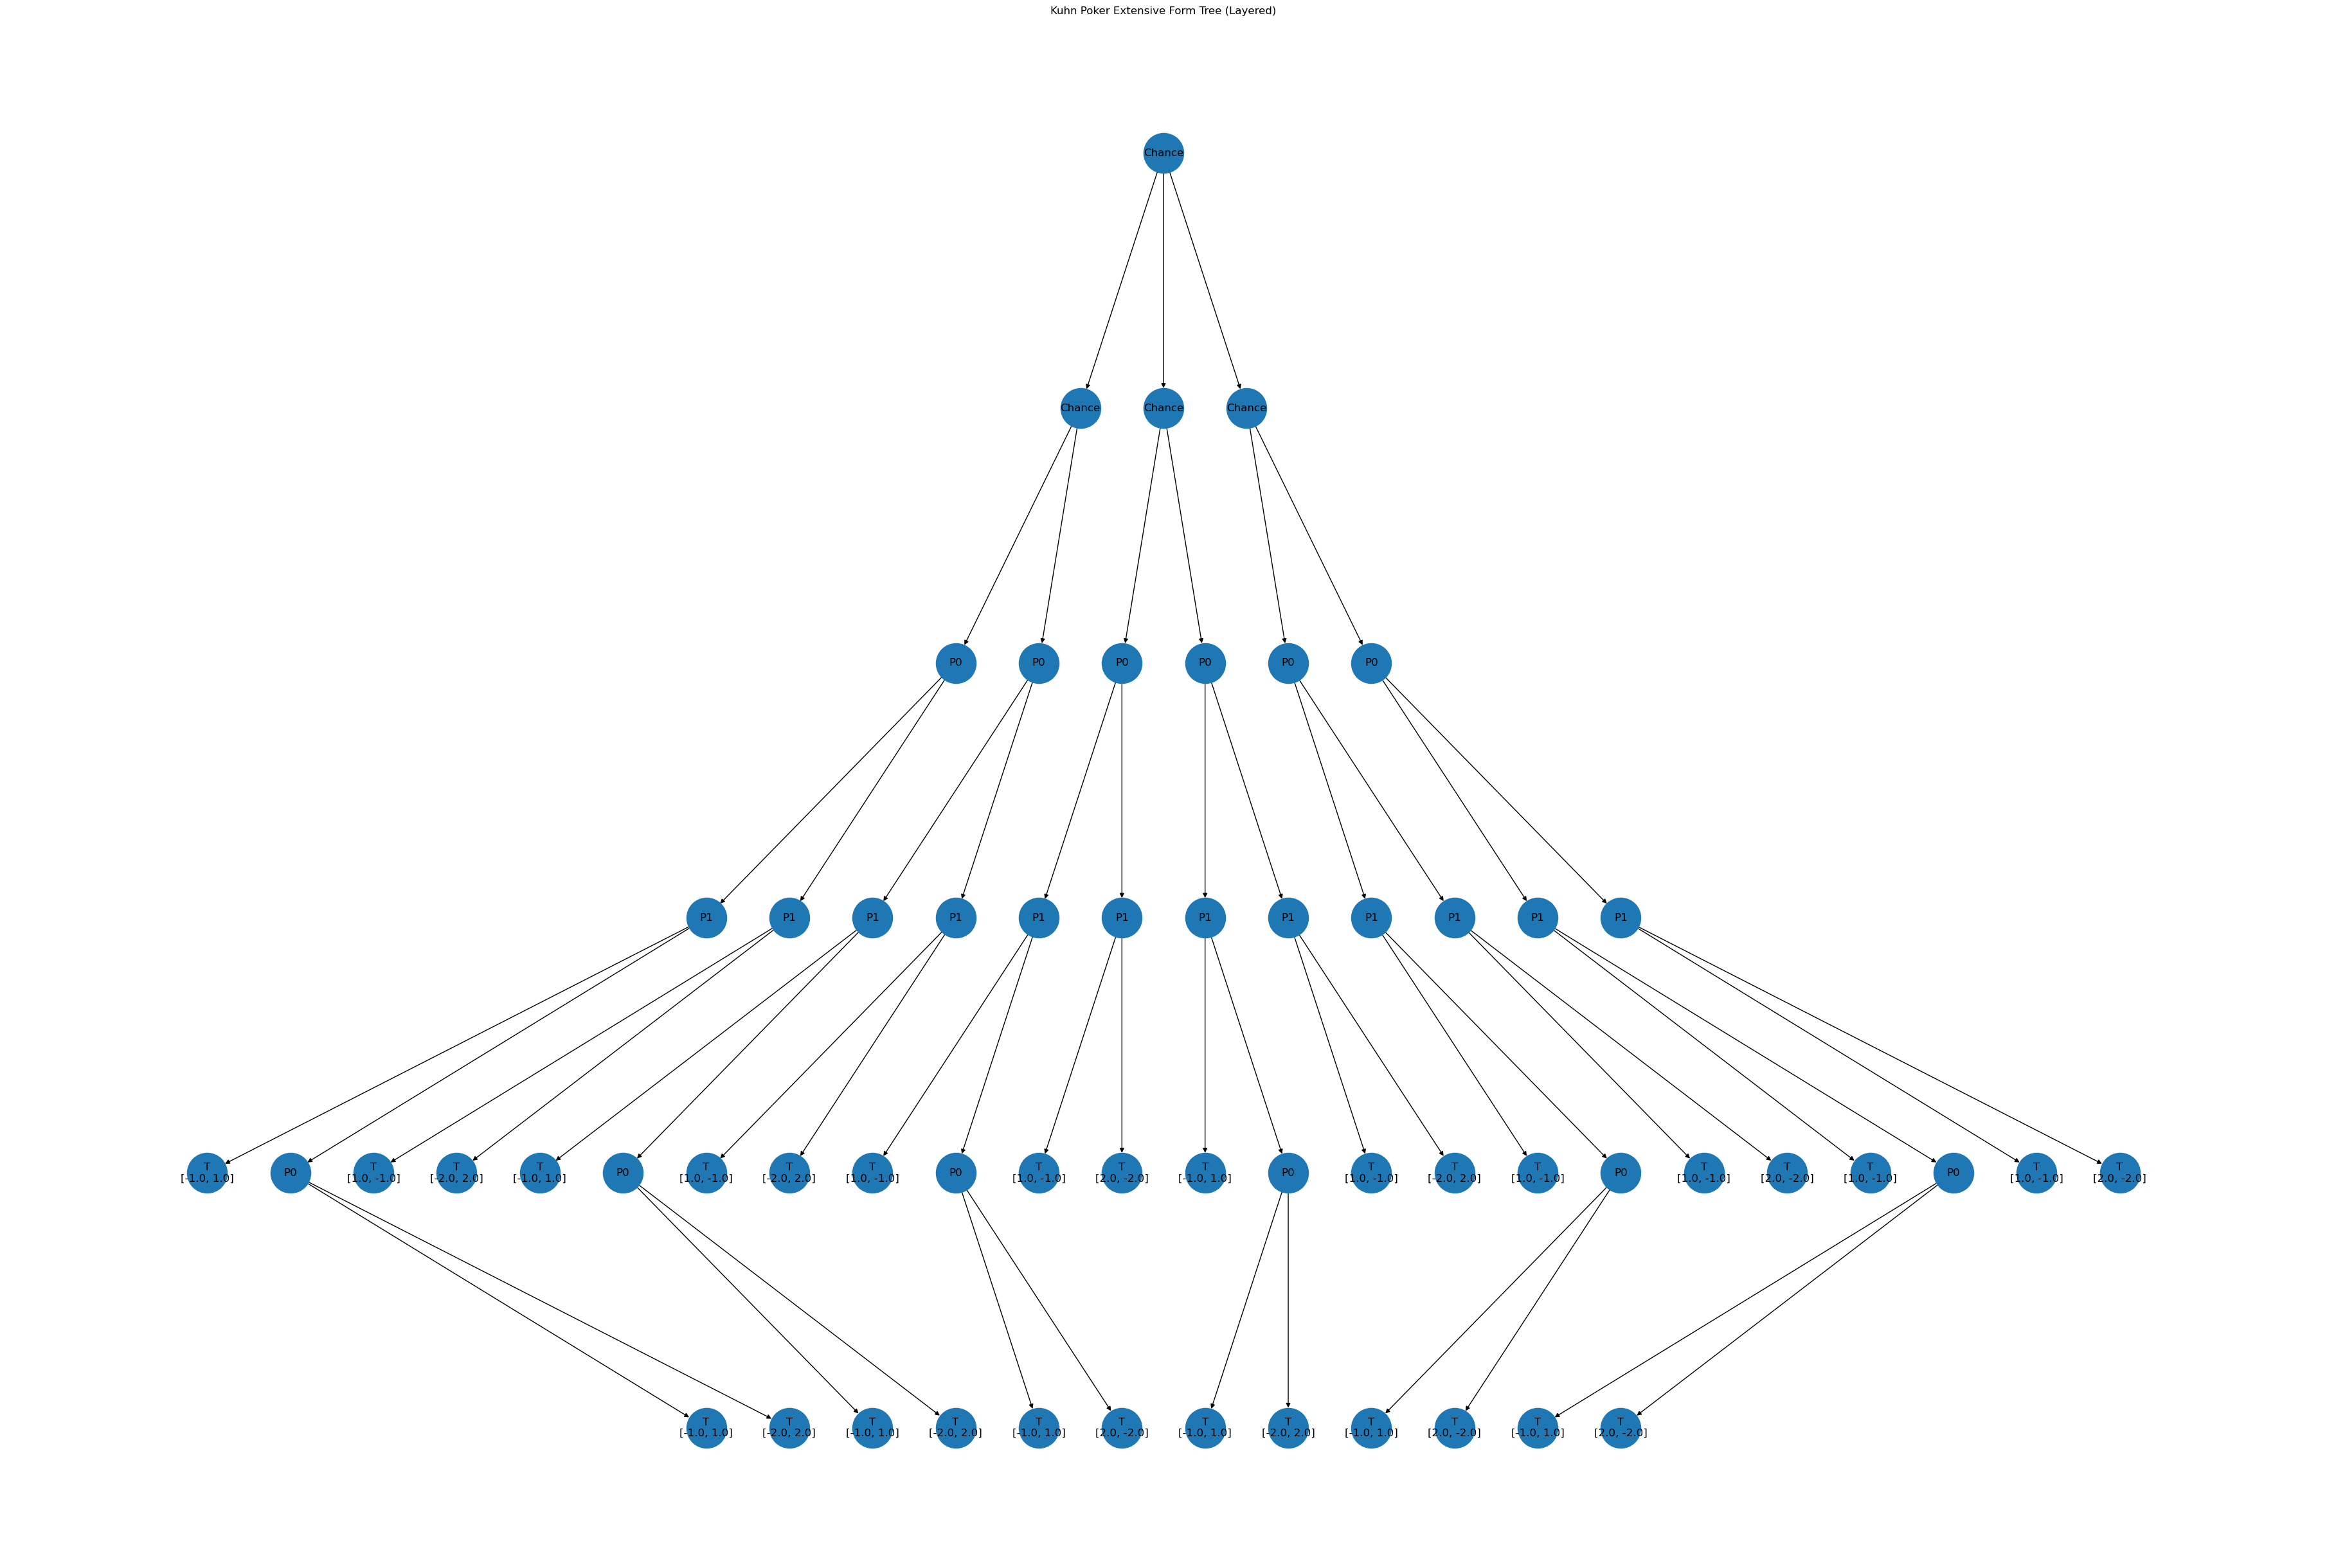

In [30]:
import pyspiel
import networkx as nx
import matplotlib.pyplot as plt

game = pyspiel.load_game("kuhn_poker")
state = game.new_initial_state()

G = nx.DiGraph()
labels = {}

node_id = 0

def traverse(state, parent=None, depth=0):
    global node_id
    
    current = node_id
    node_id += 1
    
    # Node label
    if state.is_terminal():
        label = f"T\n{state.returns()}"
    elif state.is_chance_node():
        label = "Chance"
    else:
        label = f"P{state.current_player()}"
    
    labels[current] = label
    G.add_node(current, depth=depth)
    
    if parent is not None:
        G.add_edge(parent, current)
    
    if state.is_terminal():
        return
    
    if state.is_chance_node():
        for action, prob in state.chance_outcomes():
            new_state = state.clone()
            new_state.apply_action(action)
            traverse(new_state, current, depth+1)
    else:
        for action in state.legal_actions():
            new_state = state.clone()
            new_state.apply_action(action)
            traverse(new_state, current, depth+1)

traverse(state)

# Arrange nodes by depth (hierarchical layout)
pos = {}
levels = {}

for node, data in G.nodes(data=True):
    depth = data["depth"]
    levels.setdefault(depth, []).append(node)

for depth, nodes in levels.items():
    width = len(nodes)
    for i, node in enumerate(nodes):
        pos[node] = (i - width/2, -depth)

plt.figure(figsize=(36,24))
nx.draw(G, pos, with_labels=False, node_size=2000)
nx.draw_networkx_labels(G, pos, labels)
plt.title("Kuhn Poker Extensive Form Tree (Layered)")
plt.show()